In [1]:
import os
import xarray as xr
import pandas as pd

# Load and concatenate datasets along a new dimension if needed
#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA4_sea_level.nc")
lat = ds['latitude'].values
lon = ds['longitude'].values

# If lat/lon are scalars or arrays, pair them
latlon_pairs = list(zip(lat.flatten(), lon.flatten()))
unique_latlon = list(set(latlon_pairs))  # remove duplicates

In [2]:
select_ds = ds.sel(station=2)

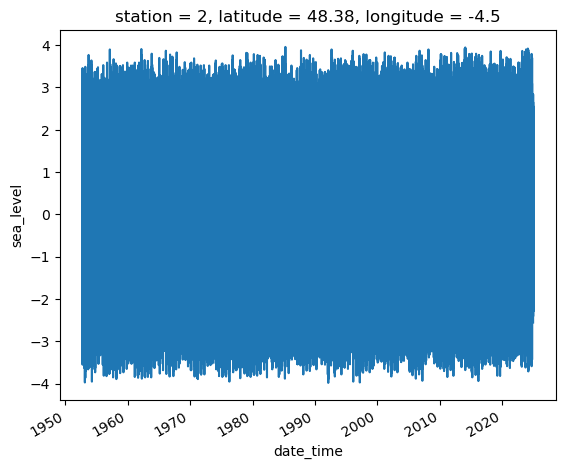

In [3]:
select_ds.sea_level.plot()

In [4]:
from utide import solve, reconstruct
import numpy as np

# Extract time in hours since start
#t = (select_ds.date_time.values - select_ds.date_time.values[0]) / np.timedelta64(1, 'D')  # days
t = select_ds["date_time"]
# Sea level values
y = select_ds['sea_level'].values

latitude = select_ds.latitude.item()

# Mask for valid (non-NaN) values
mask = ~np.isnan(y)

# Filter both time and data
t_clean = t[mask]
y_clean = y[mask]

# Now run UTide
from utide import solve, reconstruct
coef = solve(t_clean, y_clean, lat=latitude, method='ols', conf_int='linear')

# To reconstruct at original times (including NaNs), you can later do:
reconstructed = reconstruct(t, coef)  # UTide can still interpolate at full t

# Add back to dataset
select_ds['tide'] = ('time', reconstructed.h)
select_ds['residual'] = ('time', y -reconstructed.h)  # this is the "detided" signal

solve: matrix prep ... solution ... done.
prep/calcs ... done.


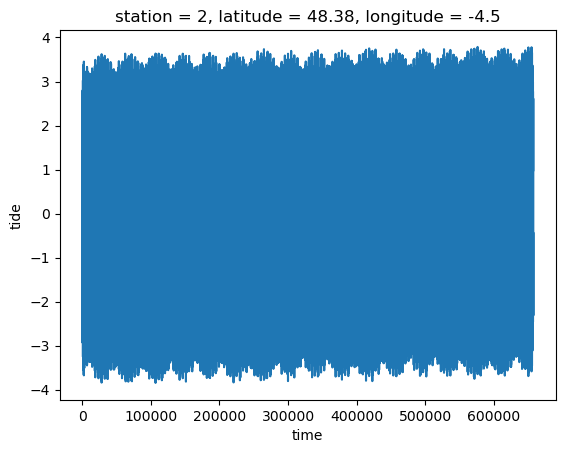

In [6]:
select_ds['tide'].plot()

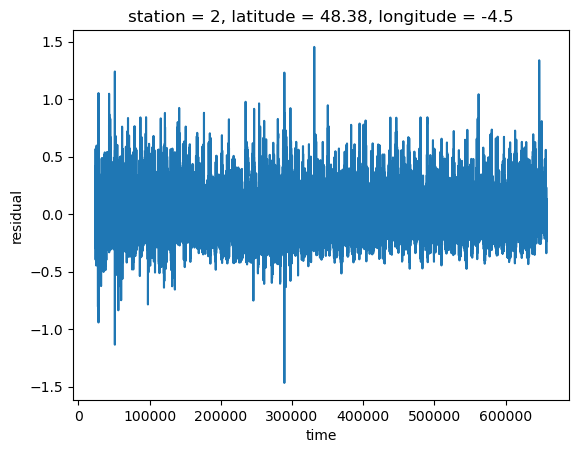

In [7]:
select_ds['residual'].plot()

In [31]:
from utide import solve, reconstruct
import numpy as np

# Extract time in hours since start
#t = (select_ds.date_time.values - select_ds.date_time.values[0]) / np.timedelta64(1, 'D')  # days
t = select_ds["date_time"]
# Sea level values
y = select_ds['sea_level'].values

latitude = select_ds.latitude.item()

# Mask for valid (non-NaN) values
mask = ~np.isnan(y)

# Filter both time and data
t_clean = t[mask]
y_clean = y[mask]

# Now run UTide
from utide import solve, reconstruct
coef = solve(t_clean, y_clean, lat=latitude, method='ols', conf_int='none')

# To reconstruct at original times (including NaNs), you can later do:
reconstructed = reconstruct(t, coef)  # UTide can still interpolate at full t

# Add back to dataset
select_ds['tide'] = ('time', reconstructed.h)
select_ds['residual'] = ('time', y -reconstructed.h)  # this is the "detided" signal

solve: matrix prep ... solution ... done.
prep/calcs ... done.


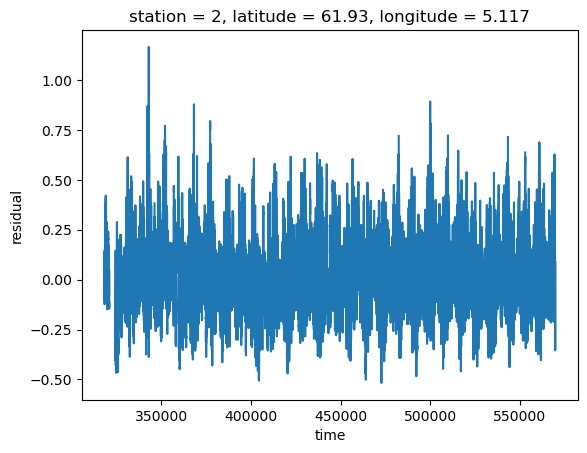

In [32]:
select_ds['residual'].plot()

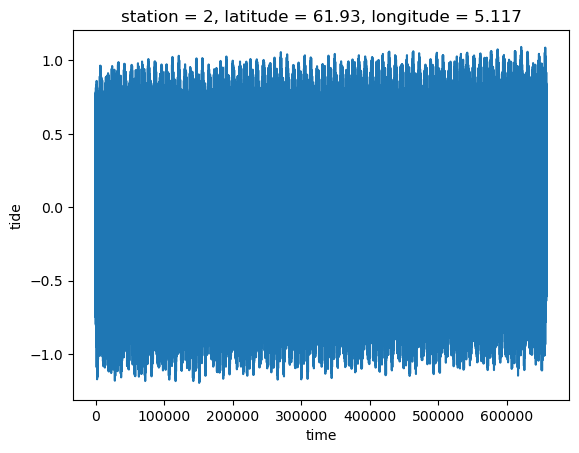

In [33]:
select_ds['tide'].plot()

In [28]:
from utide import solve, reconstruct

In [29]:
from utide import solve

coef = solve(
    time,
    time_series_u,
    time_series_v,
    lat=30,
    nodal=False,
    trend=False,
    method="ols",
    conf_int="linear",
    Rayleigh_min=0.95,
)

NameError: name 'time' is not defined

In [27]:
!python3 -m pip install pyTMD

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 881.8 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.2 MB/s eta 0:00:00


In [26]:
import numpy as np
import datetime
from utide import solve, reconstruct

In [23]:
from pytides.tide import Tide
from pytides.constituent import constituents
import pandas as pd

RuntimeError: error: unable to find a matching path for the config. please either set the environment variable TIDE_CONFIG_LOCATION or specify in the file config_location.yaml

In [11]:
import os
import datetime as dt
import pandas as pd
import xarray as xr
import hatyan
hatyan.close('all')

In [12]:
# optionally set logging level/format (and stream to prevent red background)
import logging, sys
logging.basicConfig(level="INFO", format='%(message)s', stream=sys.stdout)

In [ ]:
# defining a list of the components to be analysed ()'year' contains 94 components and the mean H0)
const_list = hatyan.get_const_list_hatyan('year')

In [14]:
# reading and editing time series (Cuxhaven dataset from UHSLC database)
# results in a pandas DataFrame a 'values' column (water level in meters) and a pd.DatetimeIndex as index
file_data_meas = 'http://uhslc.soest.hawaii.edu:80/opendap/rqds/global/hourly/h825a.nc'
times_pred = slice("2017-01-01", "2018-12-31", "10min")
ts_data = xr.open_dataset(file_data_meas)
ts_data_sel = ts_data.sea_level.isel(record_id=0).sel(time=slice(times_pred.start,times_pred.stop))
# correct from mm to meters and for 5m offset
ts_data_sel = (ts_data_sel/1000-5)
ts_meas = pd.DataFrame({'values':ts_data_sel.to_series()})
ts_meas.attrs['eenheid'] = 'm' # required for hatyan.plot_HWLW_validatestats()

In [ ]:
# inspect ts_meas
print(ts_meas)

                            values
time                              
2017-01-01 00:00:00.000000    1.56
2017-01-01 01:00:00.028800    1.85
2017-01-01 01:59:59.971200    1.95
2017-01-01 03:00:00.000000    1.68
2017-01-01 04:00:00.028800    1.02
...                            ...
2018-12-31 19:00:00.028800    1.37
2018-12-31 19:59:59.971200    1.36
2018-12-31 21:00:00.000000    1.02
2018-12-31 22:00:00.028800    0.49
2018-12-31 22:59:59.971200   -0.04

[17520 rows x 1 columns]


ANALYSIS initializing
nodalfactors         = True
fu_alltimes          = True
xfac                 = False
source               = schureman
return_allperiods    = True
analysis_perperiod   = Y
max_matrix_condition = 12

n components analyzed  = 95
analysis_perperiod=Y, separate periods are automatically determined from timeseries
analyzing 2017 of sequence ['2017', '2018']
#timesteps    = 8760
tstart        = 2017-01-01 00:00:00
tstop         = 2017-12-31 22:59:59
timestep      = None
percentage_nan in values_meas_sel: 0.00%
nodal factors (f and u) are calculated for all timesteps
folding frequencies over Nyquist frequency, which is half of the dominant timestep (1.000008 hour), there are 2 unique timesteps)
Rayleigh criterion OK (always>0.70, minimum is 1.00)
Frequencies are far enough apart (always >0.000080, minimum is 0.000114)
calculating xTx matrix
condition of xTx matrix: 3.91
matrix system solved, elapsed time: 0:00:00.023166
analyzing 2018 of sequence ['2017', '2018']
#timeste

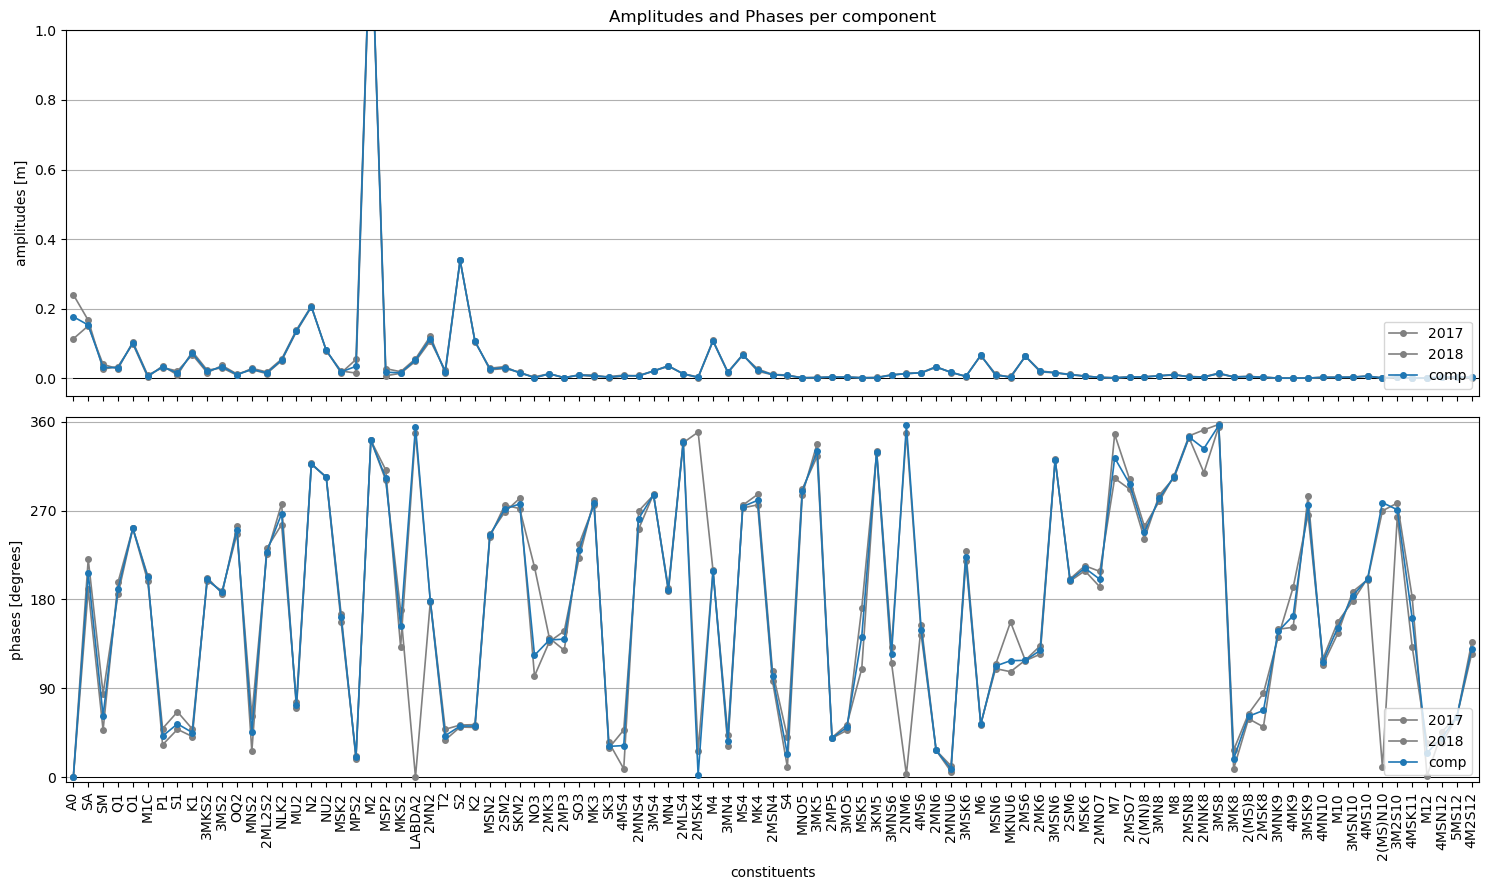

In [17]:

# tidal analysis and plotting of results 
comp_mean, comp_allperiods = hatyan.analysis(ts=ts_meas, const_list=const_list, 
                                               nodalfactors=True, return_allperiods=True,
                                               fu_alltimes=True, analysis_perperiod='Y')
fig,(ax1,ax2) = hatyan.plot_components(comp=comp_mean, comp_allperiods=comp_allperiods)
# fig.savefig('components.png')

In [ ]:
from datetime import datetime
#from pytides.tide import Tide
import numpy as np
import matplotlib.pyplot as plt

RuntimeError: error: unable to find a matching path for the config. please either set the environment variable TIDE_CONFIG_LOCATION or specify in the file config_location.yaml